<a href="https://colab.research.google.com/github/LeruaValero/projects_openbio/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%963_%D0%9B%D0%BE%D0%B3%D0%B8%D0%BD%D0%BE%D0%B2%D0%B0_%D0%92%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №3  
Формулировка:



Провести QC анализ bulk RNA-seq датасета(в дополнительной части scRNA-seq) с помощью метода PCA.

Датасет bulkRNA-seq нужно будет взять из базы данных GEO - https://www.ncbi.nlm.nih.gov/geo/

Идентификатор датасета GSE184891

Нужны будут только данные для клеточной линии HL-60



Программа минимум:

— Подготовьте датасет для построения PCA преобразования.

— Провести PCA преобразование данных и визуализировать его результаты.

— Сделать вывод на основании PCA преобразования о том насколько сходятся повторности.



Дополнение:

— Сделать вывод о том какой из наборов образцов наиболее отличается от контроля.

— Провести кластеризацию и отобразить её с использованием UMAP для scRNA-seq датасета из базы данных GEO c идентификатором GSE116256. Можно выбрать датасет для любого пациента кроме AML328.

— (*) Если PCA для bulk RNA-seq образца показывает значительное отличие между группами образцов. Может ли оно быть вызвано батч эффектом?

— (*) Зачем делают PCA перед тем как проводить tSNE или UMAP преобразование для scRNA-seq данных?

— (*) На UMAP графике вы видите что 1 и 3 кластер ближе к 4 чем 2. Можно ли считать что 2 кластер содержит больше дифференциально экспресирующихся генов по сравнению с 4, чем 1 и 3?


Подсказки:

— не стоит брать большой scRNA-seq датасет



Критерий приёмки: построить визуализауию результатов PCA преобразования для bulk RNA-seq датасета.

## Описание данных  
*Датасет bulkRNA-seq (GSE184891)* - Краткие сведения: Чтобы понять транскрипционные изменения в клетках миелоидного лейкоза под воздействием Аза, мы использовали различные клеточные линии AML и подвергали их воздействию Аза в течение нескольких периодов времени.  

*UMAP для scRNA-seq датасет (GSE116256)* -  Мы объединили секвенирование РНК одной клетки и генотипирование для профилирования 38 410 клеток из 40 аспиратов костного мозга, включая 16 пациентов с АМЛ и пять здоровых доноров. Затем мы применили классификатор машинного обучения для выделения спектра злокачественных типов клеток, количество которых варьирует между пациентами и субклонами одной и той же опухоли. Состав типов клеток коррелировал с прототипическими генетическими повреждениями, включая ассоциацию FLT3-ITD с обилием прогенитороподобных клеток. Примитивные клетки AML демонстрировали дисрегуляцию транскрипционных программ с коэкспрессией генов стволовости и миелоидного прайминга и имели прогностическое значение. Дифференцированные моноцитоподобные клетки АМЛ экспрессировали различные иммуномодулирующие гены и подавляли активность Т-клеток in vitro. В заключение мы представляем одноклеточные технологии и атлас клеточных состояний, регуляторов и маркеров АМЛ, что имеет значение для точной медицины и иммунной терапии.

## Настройка среды  

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Установим и загрузим все недостающие пакеты.

In [ ]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("DESeq2")
install.packages("pheatmap")
install.packages("factoextra")
library(factoextra)
library(ggplot2)
library(DESeq2)
library(tibble)
library(dplyr)
library("RColorBrewer")
library(pheatmap)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.1 (2024-06-14)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2'”
Old packages: 'Seurat', 'fs'

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘packa

## Загрузка данных

Загружаем матрицу ридкаунтов.

In [ ]:
dataHL60 = read.table(file="/content/drive/MyDrive/Данные для коллаба/GSE184891_count.txt",sep="\t",header=T,row.names=1)
dataHL60Matrix = as.matrix(dataHL60)
dataHL60Matrix

,HL60day0Rep1,HL60day0Rep2,HL60day0Rep3,HL60day1Rep1,HL60day1Rep2,HL60day1Rep3,OCIday0rep1,OCIday0rep2,OCIday0rep3,OCIday1rep1,⋯,HL60day8Rep1,HL60day8Rep2,HL60day8Rep3,OCIday1rep3,OCIday4rep1,OCIday4rep2,OCIday4rep3,OCIday8rep1,OCIday8rep2,OCIday8rep3
DDX11L1,0,0,0,0,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,0
WASH7P,90,107,82,222,223,308,77,70,133,227,⋯,63,57,41,69,52,77,55,38,54,73
MIR6859-1,0,4,1,6,6,5,0,1,3,5,⋯,0,5,5,1,1,0,0,2,0,2
MIR1302-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC101927589,5,1,2,3,19,8,1,1,0,1,⋯,2,10,1,0,0,2,1,0,1,0
LOC729737,207,151,244,649,702,884,31,27,48,114,⋯,201,192,213,13,25,18,21,4,27,27
LOC100996442,1,0,1,2,1,2,1,0,1,4,⋯,2,3,0,0,1,2,1,0,0,0
LOC102723897,77,78,56,216,196,301,44,38,75,111,⋯,49,50,51,27,33,26,36,9,34,31


Нам нужны только данные для клеточной линии HL-60. Для этого я отдельно через питон выбрала столбцы с HL60 и загрузила в новый csv.

https://colab.research.google.com/drive/16RLlCImoLpknBmymdEzp5Bu1bHoyIHHu?usp=sharing - тут колаб где я подготавливала данные

In [ ]:
dataHL60 = read.csv(file="/content/drive/MyDrive/Данные для коллаба/GSE184891_count_HL60.csv",sep="\t",header=T,row.names=1)
dataHL60Matrix = as.matrix(dataHL60)
dataHL60Matrix

,HL60day0Rep1,HL60day0Rep2,HL60day0Rep3,HL60day1Rep1,HL60day1Rep2,HL60day1Rep3,HL60day4Rep1,HL60day4Rep2,HL60day4Rep3,HL60day8Rep1,HL60day8Rep2,HL60day8Rep3
DDX11L1,0,0,0,0,0,0,0,0,0,0,0,0
WASH7P,90,107,82,222,223,308,57,54,68,63,57,41
MIR6859-1,0,4,1,6,6,5,2,4,1,0,5,5
MIR1302-2,0,0,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,0,0,0
LOC101927589,5,1,2,3,19,8,3,1,7,2,10,1
LOC729737,207,151,244,649,702,884,158,221,178,201,192,213
LOC100996442,1,0,1,2,1,2,0,0,0,2,3,0
LOC102723897,77,78,56,216,196,301,54,53,50,49,50,51


Загрузим описание образцов.

Создала отдельно файл через питон (ввыше ссылка на колаб). Здесь содержится полная информация о том какие образцы используются в анализе и на какие группы их нужно разбить. Описание брала с ncbi где скачиваем данные.



In [ ]:
samplesHL60Txt = read.table(file="/content/drive/MyDrive/Данные для коллаба/samples_HL60.txt",row.names=1,sep="\t",header=T)
samplesHL60Txt

,condition
,<chr>
HL60day0Rep1,HL60_Control
HL60day0Rep2,HL60_Control
HL60day0Rep3,HL60_Control
HL60day1Rep1,HL60_Day1
HL60day1Rep2,HL60_Day1
HL60day1Rep3,HL60_Day1
HL60day4Rep1,HL60_Day4
HL60day4Rep2,HL60_Day4
HL60day4Rep3,HL60_Day4


## QC анализ bulk RNA-seq датасета с использованием PCA и построения иерархической кластеризации

Проведем PCA анализ без предварительной подготовки.

In [ ]:
res.pca <- prcomp(t(dataHL60Matrix))

Оценим какую дисперсию объясняет компоненты PCA преобразования.  
По вертикали - процент объяснимой диспресии, по горизонтали - измерения. Первая компонента показывает 90% диспресии, а затем все резко падает важность компонентов.

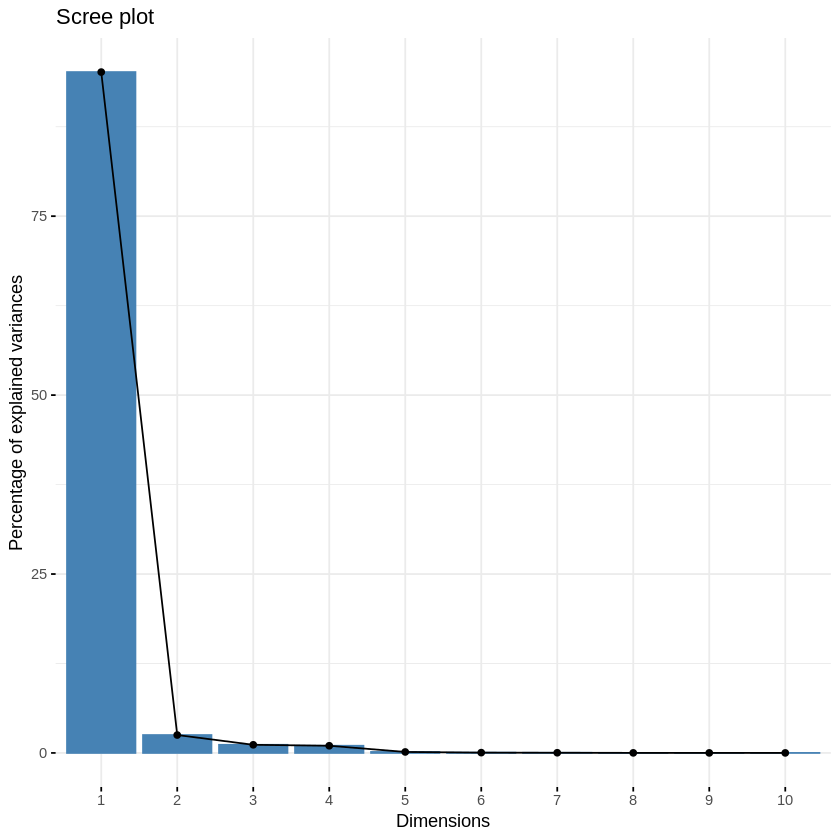

In [ ]:
fviz_eig(res.pca)

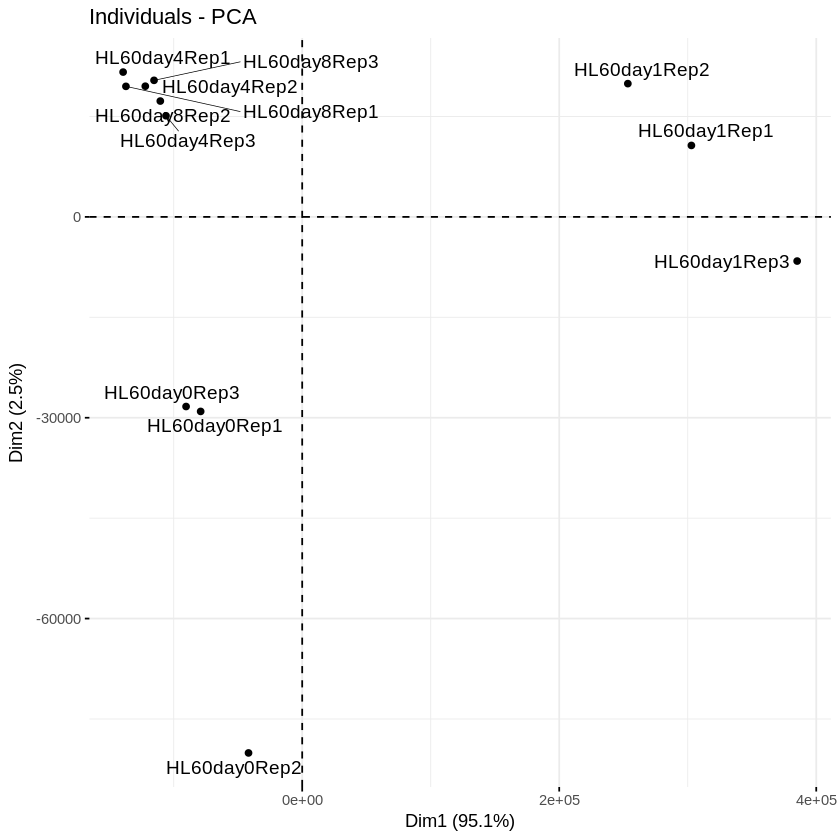

In [ ]:
fviz_pca_ind(res.pca,
             repel = TRUE
             )

Контроль один сдвинулся вниз. Реплики 4 дня и 8 дня находятся рядом. Данные разбросаны. Высокоэкспрессирующие гены дают высокую дисперсию - видим доп. шум.

Подготовим данные. Начнём с нормализации с использованием пакета DeSeq2

In [ ]:
ddsHL60 <- DESeqDataSetFromMatrix(countData = dataHL60Matrix,colData = samplesHL60Txt, design= ~condition)
ddsHL60 <- estimateSizeFactors(ddsHL60)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


Пересчитаем объясняемую дисперсию с использованием компонент, полученных с использованием PCA.

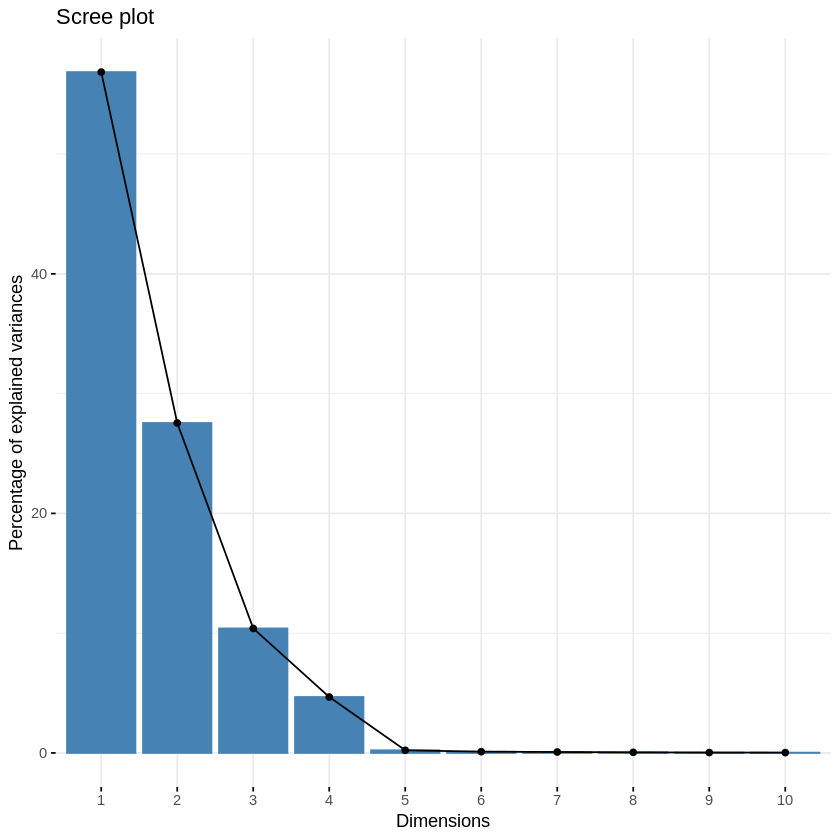

In [ ]:
res.pca_norm <- prcomp(t(counts(ddsHL60,normalized=TRUE)))
fviz_eig(res.pca_norm)

Так первая компонента чуть снизилась по значимости, но все еще доминирует. Вторая, третья и четвертая компонента теперь объясняют чуть больше, больше значат.

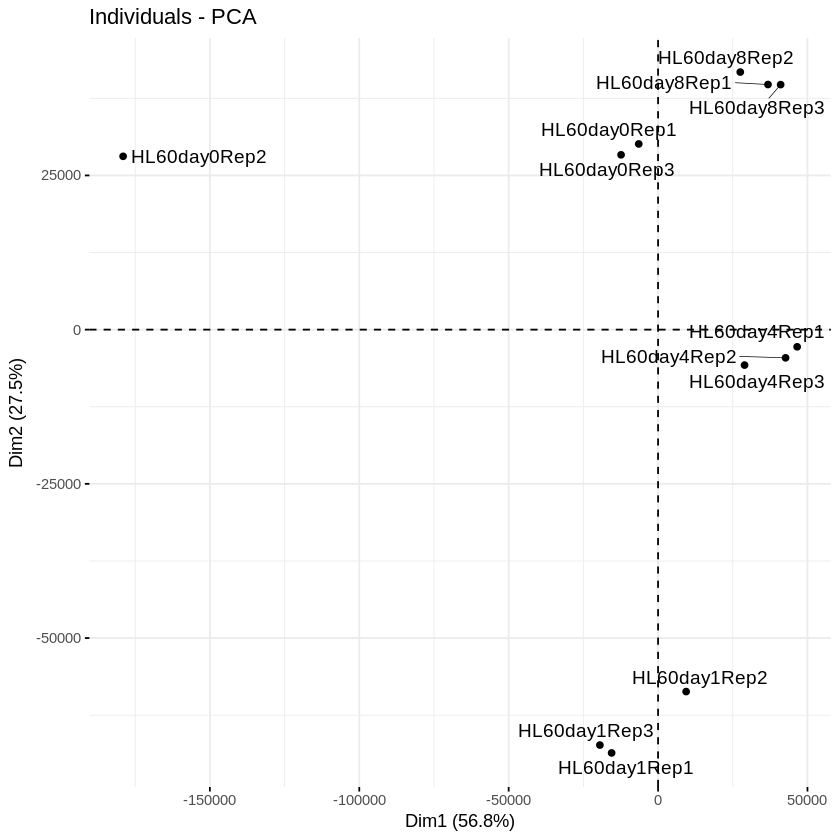

In [ ]:
fviz_pca_ind(res.pca_norm,
             repel = TRUE     # Avoid text overlapping
             )

Все равно данные разбросаны, но уже видны отдельные группы. День 1 и 4 - отдельные, но контроли и день 8 все еще вместе находятся, пересекаются.

Проведем VST преобразоваине (преобразов нормализ дисперсию) и построем PCA.

Проблема у нас в том, что по разному шумят низко эксперссируемые гены и высоко экспрессируемые гены. Больший шум у высоко экспрессируемых генов, если ничего не делать, это сильно влияет на качество PCA, из за этого точки раскидываются хаотично.  
Делаем преобразование для того, чтобы на всем диапазоне сигнала дисперсия стала более менее равномерной и можно тогда использотвать средний уровень экспрессии для характеристики образца.

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=10000 top features by variance



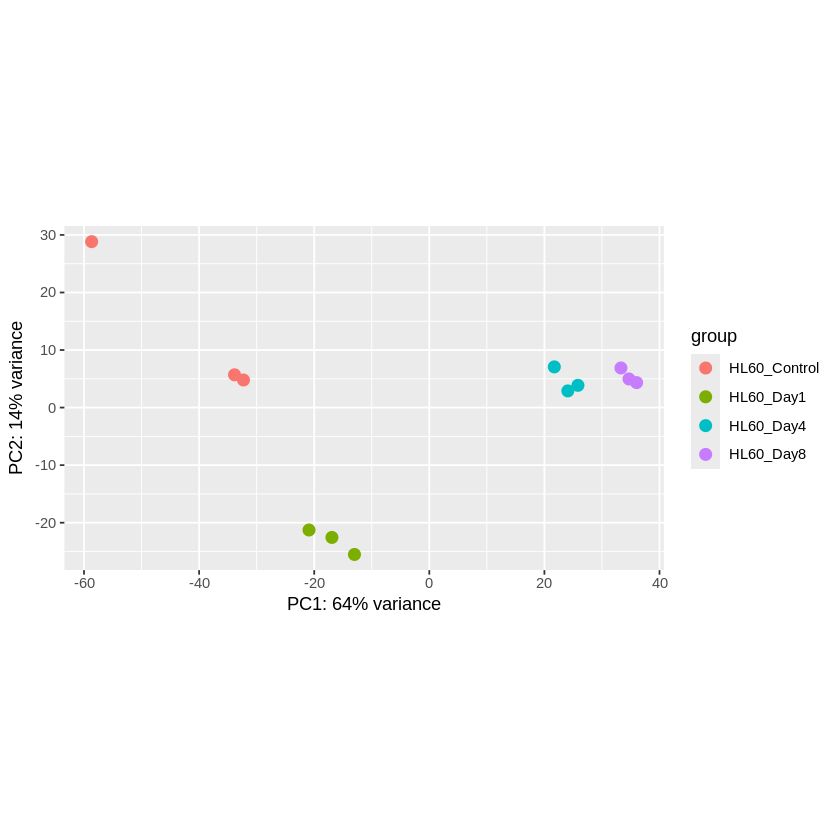

In [ ]:
ddsHL60 <- DESeqDataSetFromMatrix(countData = dataHL60Matrix,colData = samplesHL60Txt, design= ~condition)
vsdHL60 <- vst(ddsHL60, blind=TRUE)
plotPCA(vsdHL60, intgroup=c("condition"),ntop=10000)

 Картинка уже похожа на то что мы ожидали. Потому что у нас есть для каждого condition по три повтросноти, и мы ожидаем что внутри группы повторности будут друг на друга похожи, а между группами образцы будут отличаться. Видим что один контроль правда отбился от группы своей.

— Сделать вывод о том какой из наборов образцов наиболее отличается от контроля.  
Образец 1 дня отбился от контроля. 4 и 8 день похожи.


  

Попробуем по другому визуализировать сходство между образцами. Построим тепловую карту совместно с дендрограммами.

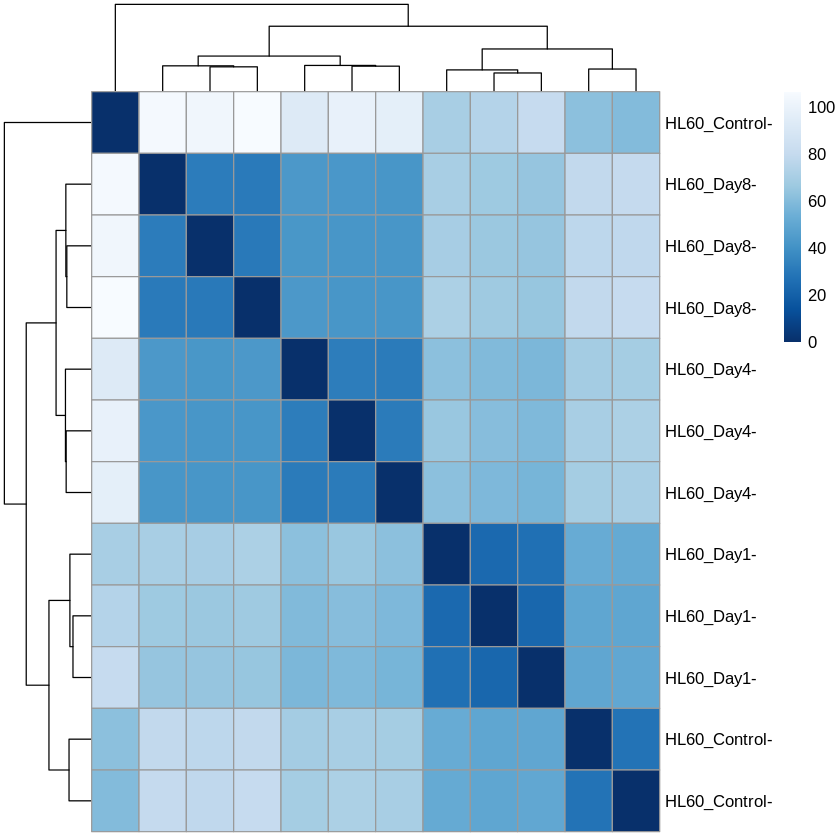

In [ ]:
sampleDistsHL60 <- dist(t(assay(vsdHL60)))
sampleDistMatrixHL60 <- as.matrix(sampleDistsHL60)
rownames(sampleDistMatrixHL60) <- paste(vsdHL60$condition, vsdHL60$type, sep="-")
colnames(sampleDistMatrixHL60) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrixHL60,
         clustering_distance_rows=sampleDistsHL60,
         clustering_distance_cols=sampleDistsHL60,
         col=colors)

Дендрограммы и тепловая карта тоже достаточно красноречиво показывают сходство повторностей образцов. Строки и столбцы отсортированы по сходству образцов.
Видим, что один контроль не имеет сходство с другими контролями, он находится отдельно.  

— (*) Зачем делают PCA перед тем как проводить tSNE или UMAP преобразование для scRNA-seq данных?

PCA проводят перед tSNE или UMAP для снижение размерности и улучшение производительности.   
PCA помогает снизить размерность данных, сохраняя при этом важные характеристики.  
Яявлясь линейным методом, PCA работает быстрее, чем t-SNE и UMAP. Он позволяет значительно уменьшить количество признаков до разумного уровня перед применением более сложных алгоритмов, таких как t-SNE или UMAP.
Также PCA сохраняет глобальную структуру данных, что позволяет лучше понять общие тенденции и вариации в наборе данных. Это важно для дальнейшего анализа, так как t-SNE и UMAP ориентированы на локальные структуры и могут не учитывать глобальные паттерны.
Еще PCA помогает удалить шум из данных, оставляя только те компоненты, которые объясняют наибольшую долю вариации.

— (*) Если PCA для bulk RNA-seq образца показывает значительное отличие между группами образцов. Может ли оно быть вызвано батч эффектом?

*Батч-эффект — это систематическая ошибка, возникающая из-за различий в обработке образцов, которые были собраны или обработаны в разные временные промежутки или при различных условиях.*  

Да, может быть вызвано батч-эффектом. Тогда образцы могут кластеризоваться по признаку сервиса секвенирования например.

#scRNA-seq

— Провести кластеризацию и отобразить её с использованием UMAP для scRNA-seq датасета из базы данных GEO. Взяла датасет для пациента AML314

## Подготовка среды

In [ ]:
if (!requireNamespace("remotes", quietly = TRUE)) {
  install.packages("remotes")
}

remotes::install_version("Seurat", "4.4.0", repos = c("https://satijalab.r-universe.dev", getOption("repos")))


install.packages("harmony")


if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("glmGamPoi")

library(Seurat)
library(Matrix)
library(rlang)
library(tidyverse)
library(harmony)
library(ggpubr)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.1 (2024-06-14)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'glmGamPoi'”
Old packages: 'Seurat', 'fs'

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘Seurat’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays



Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand



Attac

In [ ]:
sessionInfo() #для просмотра какие пакеты установлены и какие у них версии

R version 4.4.1 (2024-06-14)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggpubr_0.6.0                harmony_1.2.1              
 [3] Rcpp_1.0.13                 lubridate_1.9.3            
 [5] forcats_1.0.0               stringr_1.

## Загрузка данных и создание Seurat объекта

Загрузим датасеты и объединим их в одни dataframe. Нулевой день для пациента, 31 день и второй контроль.

In [ ]:
options(ggrepel.max.overlaps = Inf)
d0AML314 = read.table(file='/content/drive/MyDrive/Данные для коллаба/AML314-D0.dem.txt',header=T,sep='\t')
d31AML314 = read.table(file='/content/drive/MyDrive/Данные для коллаба/AML314-D31.dem.txt',header=T,sep='\t')
BM2 = read.table(file='/content/drive/MyDrive/Данные для коллаба/BM2.dem.txt',header=T,sep='\t')


In [ ]:
d0d31AML314 <- merge(d0AML314,d31AML314,by="Gene")
d0d31BM2AML314 <- merge(d0d31AML314,BM2,by="Gene")
ncol(d0d31BM2AML314)

[1] 697

Создадим Seurat объект

In [ ]:
data_ncol <- d0d31BM2AML314[,2:ncol(d0d31BM2AML314)]
rownames(data_ncol)<-t(d0d31BM2AML314["Gene"])


mydata <- CreateSeuratObject(counts = data_ncol, min.cells = 3,min.features=200, project = "GSE116256") # фильтрация

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


## QC данных

Проведём подсчёт уровня экспрессии митохондриальных генов и проведём визуальный контроль основных признаков, которые могут говорить о качестве данных

In [ ]:
mydata[["percent.mt"]] <- PercentageFeatureSet(mydata, pattern = "^MT-")

nFeature_RNA - количество генов, которые отличны от нуля для клетки (каждая точка - клетка).  
Большинство клеток находится меньше чем в районе 1тыс.  
nCount_RNA - у каждого признака есть уровень сигнала, количетсво ридов которым они соответствуют, т.е. это сколько ридов приходится на ген и на клетку.

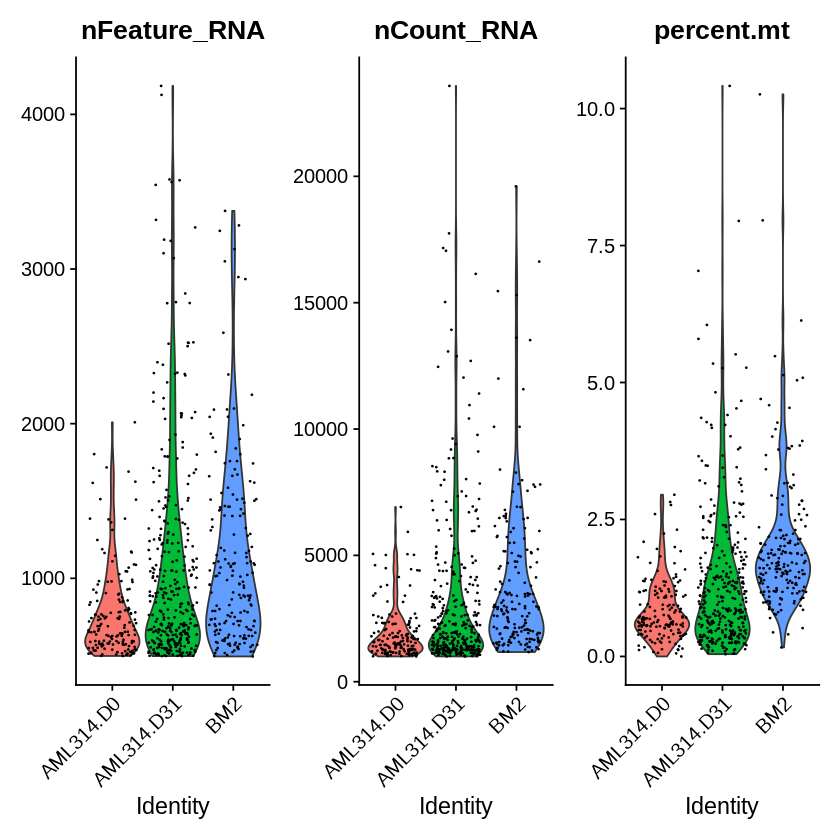

In [ ]:
VlnPlot(mydata, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

Проведём фильтрацию по проценту экспрессирующихся митохондриальных генов.

In [ ]:
mydata <- subset(x=mydata, subset=percent.mt<5)

## Визуализация данных
Перед визуализацией необходимо провести нормализацию. Для этих целей будем использовать SCTransform.

In [ ]:
mydata <- SCTransform(mydata,
                      method = "glmGamPoi",
                      vars.to.regress = "percent.mt",
                      verbose = F,conserve.memory=TRUE)

Will not return corrected UMI because residual type is not set to 'pearson'



Проведём виузализацию данных двумя способами PCA + tSNE и PCA + UMAP.

Сначала делаем PCA. И оцениваем число главных компонент объясняющих основную долю дисперсии.

PC_ 1 
Positive:  LYZ, TMSB4X, SRGN, MNDA, S100A9, S100A8, B2M, CTSS, AIF1, TMSB10 
	   VCAN, FCN1, ANXA1, HLA-DRA, CYBB, PSAP, CSTA, PTPRC, TYROBP, FTL 
	   IFI30, LCP1, VIM, ACTB, ARPC5, RNASE2, SAMHD1, FGL2, NAMPT, RGS2 
Negative:  HBB, AHSP, HBD, HBA2, HBG2, CA1, HBG1, HBA1, HEMGN, HIST1H4C 
	   TFRC, GYPA, HBM, CA2, ATPIF1, SLC4A1, PRDX2, CD36, HIST1H1B, SLC25A37 
	   HMGB2, HBE1, REXO2, HSPD1, CKS2, DLGAP5, CENPF, EIF1AY, APOOL, HIST1H1D 
PC_ 2 
Positive:  LYZ, HBB, S100A8, S100A9, AHSP, MNDA, HBD, HBA2, HIST1H4C, VCAN 
	   HBG2, HMGB2, S100A6, CA1, SRGN, FCN1, HBA1, CTSS, S100A4, HBG1 
	   CSTA, AIF1, HBM, GYPA, CD36, HEMGN, CYBB, CA2, RNASE2, SLC4A1 
Negative:  EEF1A1, RPS27, RPS19, RPS18, CD69, PIK3R1, RPS14, ETS1, ZFAS1, SLC38A1 
	   REL, CD52, CYLD, RUNX3, HLA-E, MAN1A2, IFITM1, SYNE2, IL7R, MSI2 
	   SPINK2, B2M, LTB, PRRC2C, HSPA5, CREBRF, SH2D1A, CD3D, PNISR, PPP1R16B 
PC_ 3 
Positive:  SYNE2, ETS1, HBB, CD2, CD3D, HBA2, CD52, IL32, IL7R, FYB1 
	   CD3G, ARL4C, HBG2, SLFN

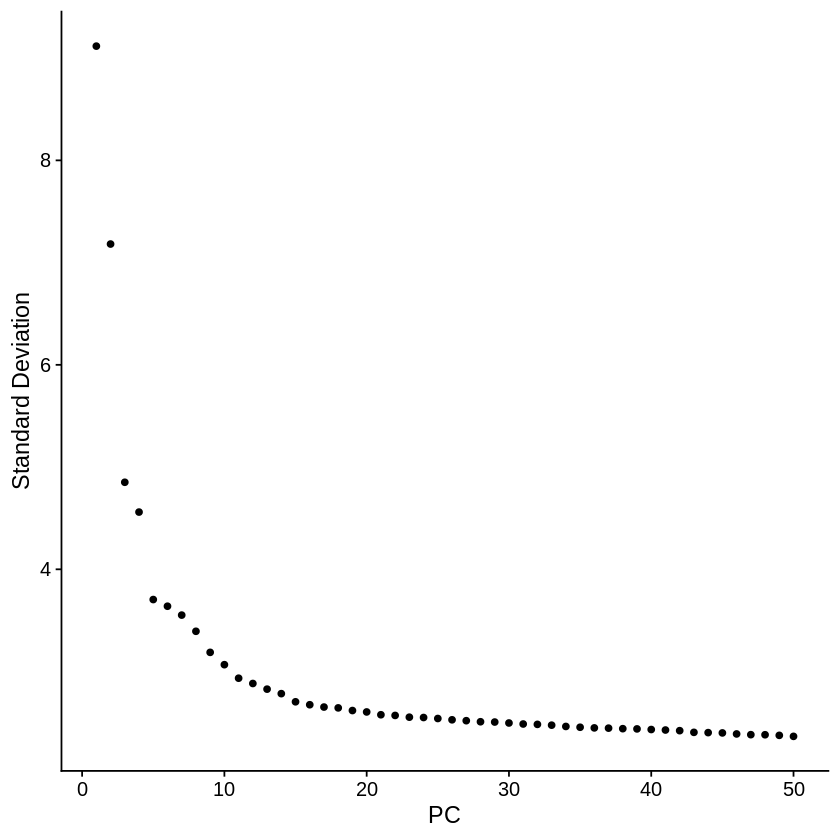

In [ ]:
mydata <- RunPCA(mydata, npcs = 50)
ElbowPlot(mydata, ndims = 50)

По точки перегиба графика видим что это примерно 30 компонент. Будем их использовать для построения tSNE и UMAP преобразований.

Для начала построим PCA для 1 и 2 главной компоненты.

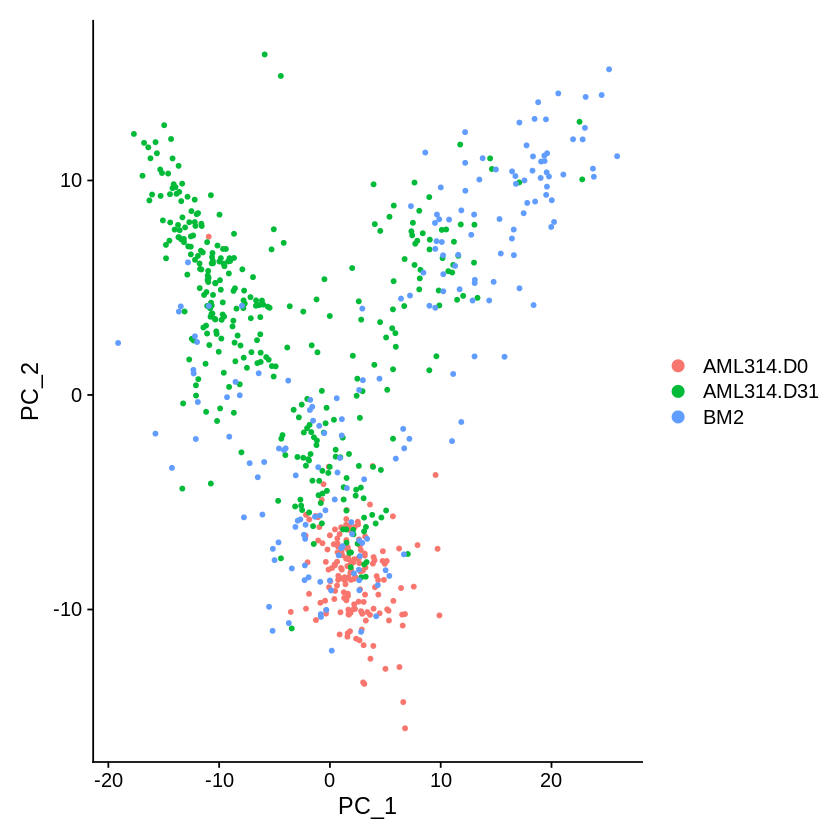

In [ ]:
DimPlot(mydata, reduction = "pca")

На основе PCA строим t-SNE.  
t-SNE - пытается сохранить структуру кластеров.  
perplexity - ожидаемый размер кластеров.  

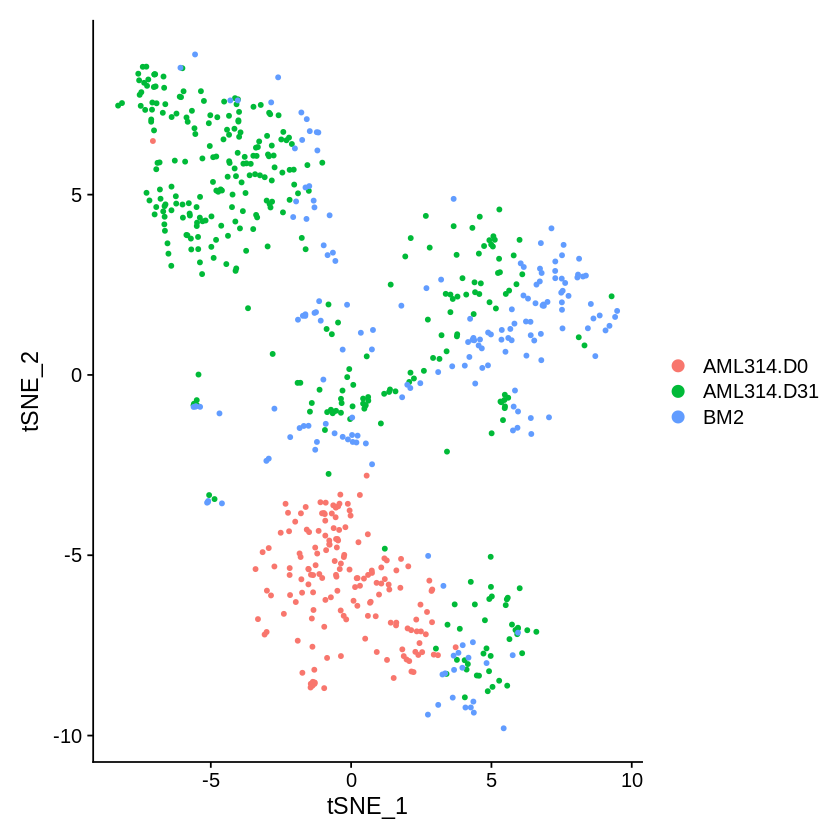

In [ ]:
mydata <- RunTSNE(mydata, dims = 1:30,perplexity=100.0)
DimPlot(mydata, reduction = "tsne")

и UMAP  
n.neighbors - тоже самое что perplexity у tSNE.  
min.dist - позволяет регулировать размер кластеров, которые отображаются, насколько сжаты будут кластеры.

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
18:27:59 UMAP embedding parameters a = 1.896 b = 0.8006

18:27:59 Read 680 rows and found 30 numeric columns

18:27:59 Using Annoy for neighbor search, n_neighbors = 10

18:27:59 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:27:59 Writing NN index file to temp file /tmp/Rtmpdsd6pf/fileed9949b05550

18:27:59 Searching Annoy index using 1 thread, search_k = 1000

18:27:59 Annoy recall = 100%

18:28:00 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

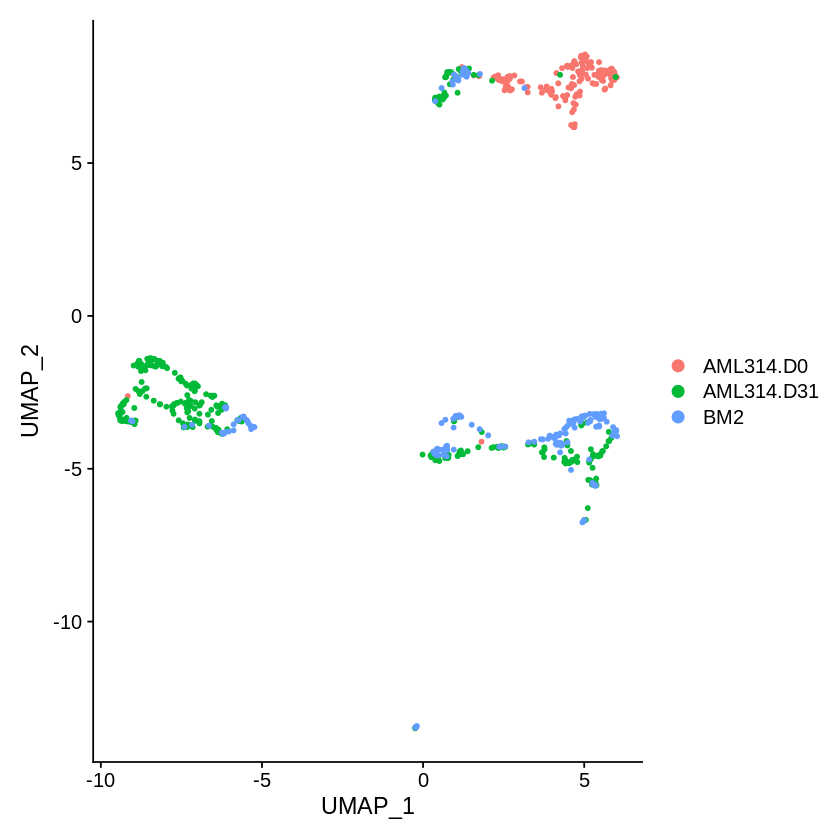

In [ ]:
mydata <- RunUMAP(mydata, dims = 1:30,n.neighbors = 10, min.dist=0.01)
DimPlot(mydata, reduction = "umap")

Здесь более менее сохраняется глобальная структура. Видим три кластера.   

Так как B2 образцы - конртоль таки выделяются в отдельные кластеры на рисунке, они чистые и без клеток из других образцов.

Попробуем использовать Harmony для проведения батч-коррекции.

In [ ]:
mydata_hrmn <- mydata %>%
  RunHarmony("orig.ident", assay.use = "SCT")

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations



Проведём кластеризацию с использованием SNN метода.  

Этот метод сходен с DBSCAN, но в качестве меры сходства между образцами (растояний) используется число разделяемых ближайших соседей.

18:28:12 UMAP embedding parameters a = 0.9922 b = 1.112

18:28:12 Read 680 rows and found 30 numeric columns

18:28:12 Using Annoy for neighbor search, n_neighbors = 30

18:28:12 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:28:12 Writing NN index file to temp file /tmp/Rtmpdsd6pf/fileed9935092387

18:28:12 Searching Annoy index using 1 thread, search_k = 3000

18:28:13 Annoy recall = 100%

18:28:13 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:28:15 Initializing from normalized Laplacian + noise (using irlba)

18:28:15 Commencing optimization for 500 epochs, with 26888 positive edges

18:28:17 Optimization finished

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 680
Number of edges: 28274

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6057
Number of communities: 8
Elapsed time: 0 seconds


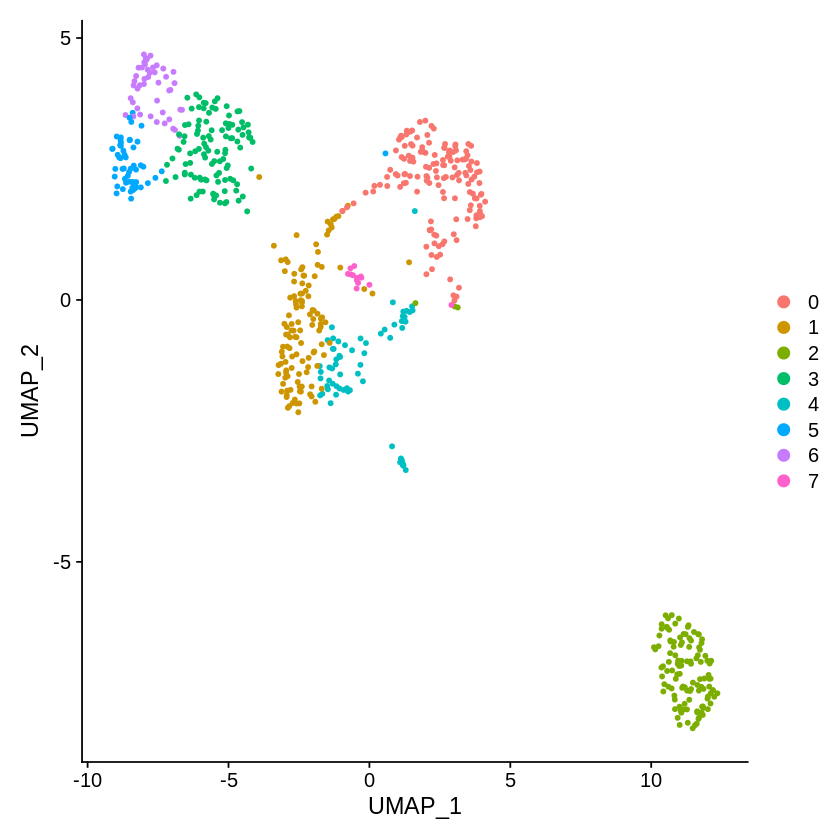

In [ ]:
DefaultAssay(mydata_hrmn) <- "SCT"
mydata_hrmn <- mydata_hrmn %>%
  RunUMAP(reduction = "harmony", dims = 1:30) %>%
  FindNeighbors(reduction = "harmony", dims = 1:30) %>%
  FindClusters(resolution = 1.7)
DimPlot(mydata_hrmn, reduction = "umap")

Видим получившиеся кластеры.

И напоследок картинка помогающая понять, что клетки B2 образца теперь более менее похожи на клетки остальных образцов. Тоесть удалось справится с батч эффектом.  

Видим, что клетки с образцами опыта смешались, что контроль и опыт оказываются вместе.

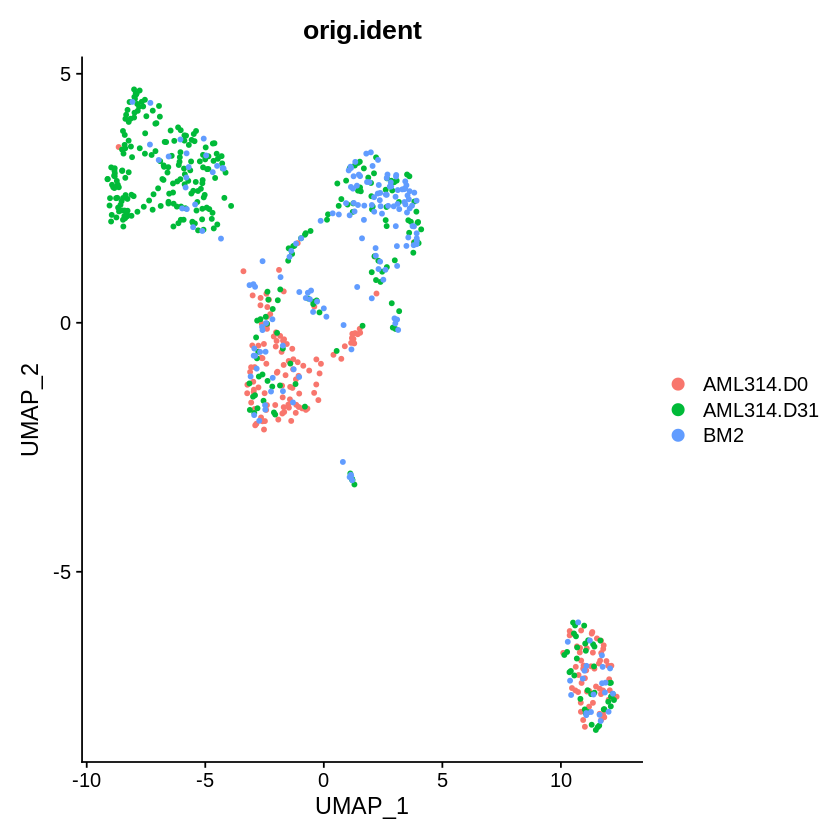

In [ ]:
DimPlot(mydata_hrmn, reduction = "umap",group.by="orig.ident")